# Alpha functions

The attractive parameter of every CEOS has a dependance with temperature, given by an $\alpha(T)$ function. Normally every CEOS has a default $\alpha$ function, but the `yaeos` API allows you to modify them. This can be done with the `.set_alpha` method. This method replaces the default alpha function with one defined by the user. 
This definition is done with different objects already defined inside `yaeos`.

The available alpha functions are:

- AlphaSoave
- AlphaRKPR
- AlphaMathiasCopeman

## AlphaSoave

The $\alpha$ function defined by Soave for the SoaveRedlichKwong EoS:

$$
\alpha(T_r)=(1+k(1−\sqrt{Tr}))^2
$$

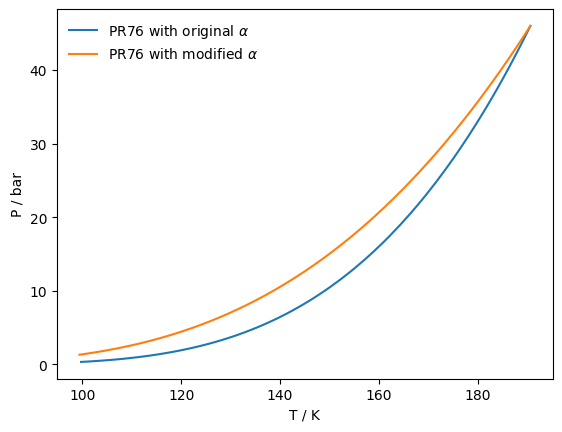

In [39]:
import yaeos

import matplotlib.pyplot as plt

import numpy as np

tcs = np.array([190.6, 369.8])  # critical temperatures [K]
pcs = np.array([45.99, 42.48])  # critical pressures [bar]
w = np.array([0.0115, 0.0866])  # acentric factors [-]

model_pr76 = yaeos.PengRobinson76(tcs, pcs, w)
psat_pr76 = model_pr76.pure_saturation_pressures(1)

# Define the alpha soave with a value of k=0 for the first component and
# 10.3 for the second one. Just as example values.
k = [00.000, 10.3]
alphasoave = yaeos.AlphaSoave(k=k)

model_pr76.set_alpha(alphasoave)
psat_pr76_modified = model_pr76.pure_saturation_pressures(1)

plt.plot(psat_pr76["T"], psat_pr76["P"], label=r"PR76 with original $\alpha$")
plt.plot(psat_pr76_modified["T"], psat_pr76_modified["P"], label=r"PR76 with modified $\alpha$");
plt.legend(frameon=False)

plt.xlabel("T / K")
plt.ylabel("P / bar");

## Alpha RKPR

The RKPR EoS uses a different $\alpha$ function. This function changes the
functionality with Temperature. Being inversely proportional to the reduced
temperature $T_r$, with an exponent $k$

$$
\alpha = \left(\frac{3}{2 + T_r}\right)^k
$$

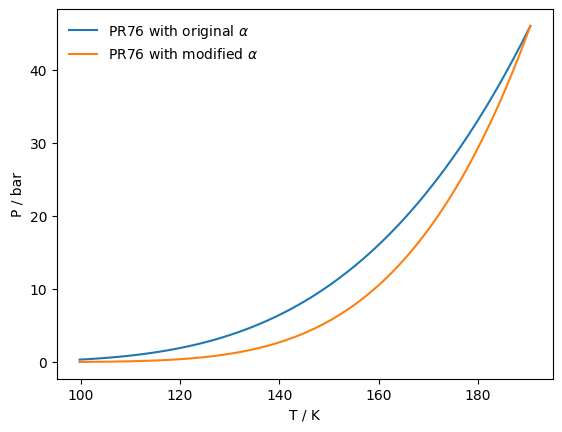

In [38]:
import yaeos

import matplotlib.pyplot as plt

import numpy as np

k = [3.000, 10.3]
alpharkpr = yaeos.AlphaRKPR(k=k)

tcs = np.array([190.6, 369.8])  # critical temperatures [K]
pcs = np.array([45.99, 42.48])  # critical pressures [bar]
w = np.array([0.0115, 0.0866])  # acentric factors [-]

model_pr76 = yaeos.PengRobinson76(tcs, pcs, w)
psat_pr76 = model_pr76.pure_saturation_pressures(1)

model_pr76.set_alpha(alpharkpr)
psat_pr76_modified = model_pr76.pure_saturation_pressures(1)

plt.plot(psat_pr76["T"], psat_pr76["P"], label=r"PR76 with original $\alpha$")
plt.plot(psat_pr76_modified["T"], psat_pr76_modified["P"], label=r"PR76 with modified $\alpha$");
plt.legend(frameon=False)
plt.xlabel("T / K")
plt.ylabel("P / bar");

## Alpha Mathias-Copeman
The alpha function defined by Mathias and Copeman. This function consists in
a piecewise function, either for temperatures above or below the critical point.
Above the critical point, the same functionality as the Soave alpha is used. But,
for temperatures below the critical point, a third order polinomial is used.

\begin{cases}
    \alpha = (1 + c_1(1 - \sqrt{T_r}))^2  & \rightarrow T_r > 1\\
    \alpha = (-c_1(\sqrt{T_r} - 1) + c_2(\sqrt{Tr} - 1)^2 - c_3(\sqrt{Tr} - 1)^3 + 1)^2 &  \rightarrow T_r <= 1
\end{cases}

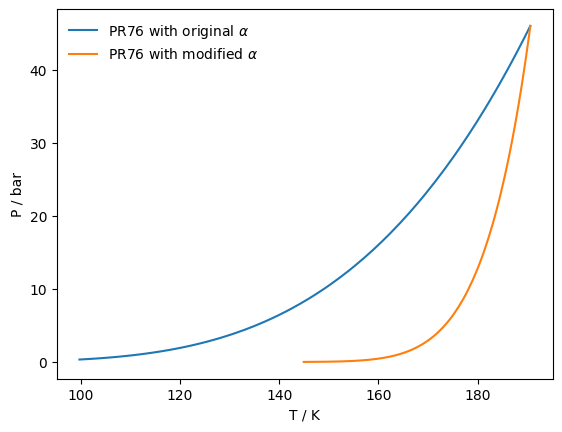

In [40]:

import yaeos

import matplotlib.pyplot as plt

import numpy as np

c1 = [5.000, 0.3]
c2 = [0.000, 0.3]
c3 = [0.9, 0.3]

alphamc = yaeos.AlphaMathiasCopeman(c1, c2, c3)

tcs = np.array([190.6, 369.8])  # critical temperatures [K]
pcs = np.array([45.99, 42.48])  # critical pressures [bar]
w = np.array([0.0115, 0.0866])  # acentric factors [-]

model_pr76 = yaeos.PengRobinson76(tcs, pcs, w)
psat_pr76 = model_pr76.pure_saturation_pressures(1)

model_pr76.set_alpha(alphamc)
psat_pr76_modified = model_pr76.pure_saturation_pressures(1)

plt.plot(psat_pr76["T"], psat_pr76["P"], label=r"PR76 with original $\alpha$")
plt.plot(psat_pr76_modified["T"], psat_pr76_modified["P"], label=r"PR76 with modified $\alpha$");
plt.legend(frameon=False)
plt.xlabel("T / K")
plt.ylabel("P / bar");
